In [1]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.13.0+cpu
Torchvision: 0.28.0+cpu


# Practice 2 – Mô hình ResNet-18

Notebook này thực hiện hai chiến lược huấn luyện:

 ResNet-18 A: đóng băng backbone và chỉ huấn luyện lớp `fc`.
 
 ResNet-18 B: fine-tuning `layer4` và lớp `fc`.

Hai thí nghiệm sẽ sử dụng cùng learning rate, batch size, optimizer và số epoch để bảo đảm so sánh công bằng.

## 1. Mục tiêu
 Tải mô hình ResNet-18 pre-trained.

 Khảo sát kiến trúc mô hình.

 Xác định lớp phân loại cuối `model.fc`.

 Thay lớp cuối để đầu ra có 10 lớp.

 Thực hiện transfer learning bằng cách chỉ huấn luyện lớp `fc`.

 Thực hiện fine-tuning bằng cách mở `layer4` và `fc`.

 Đếm tổng số tham số và số tham số được huấn luyện.


 Kiểm tra kích thước đầu ra của mô hình.

In [2]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "Practice_2":
    PROJECT_ROOT = CURRENT_DIR

elif (CURRENT_DIR / "Practice_2").exists():
    PROJECT_ROOT = CURRENT_DIR / "Practice_2"

elif CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent

else:
    raise FileNotFoundError(
        "Không tìm thấy thư mục Practice_2."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Thư mục hiện tại:", CURRENT_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("src tồn tại:", (PROJECT_ROOT / "src").exists())
print(
    "resnet18.py tồn tại:",
    (PROJECT_ROOT / "src" / "models" / "resnet18.py").exists()
)

Thư mục hiện tại: D:\DEEP\UTH-Deep-Learning-nhom2\Practice_2\notebooks
PROJECT_ROOT: D:\DEEP\UTH-Deep-Learning-nhom2\Practice_2
src tồn tại: True
resnet18.py tồn tại: True


In [3]:
import torch
import pandas as pd

from src.models.resnet18 import (
    build_resnet18_fc_only,
    build_resnet18_finetune_layer4,
    count_parameters,
    get_trainable_parameter_names
)

print("Import thư viện và mô hình thành công.")

Import thư viện và mô hình thành công.


## 2. Thiết lập thiết bị

Mô hình sẽ sử dụng GPU nếu CUDA khả dụng. Nếu không có GPU, chương trình sẽ tự động sử dụng CPU.

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Thiết bị đang sử dụng:", device)

Thiết bị đang sử dụng: cpu


## 3. ResNet-18 A – Chỉ huấn luyện lớp fc

Trong thí nghiệm này, toàn bộ backbone của ResNet-18 được đóng băng. Chỉ lớp phân loại cuối `model.fc` được cập nhật trọng số.

Đây là chiến lược transfer learning, trong đó mô hình sử dụng các đặc trưng đã học từ ImageNet và chỉ huấn luyện classifier mới cho CIFAR-10.

In [5]:
model_a = build_resnet18_fc_only(
    num_classes=10,
    use_pretrained=True
)

model_a = model_a.to(device)

print("Đã tạo ResNet-18 A.")

Đã tạo ResNet-18 A.


In [ ]:
print(model_a)

### Phân tích kiến trúc ResNet-18

 `conv1`: lớp tích chập đầu tiên, nhận ảnh đầu vào.

 `bn1`: chuẩn hóa đầu ra của lớp tích chập.

 `relu`: hàm kích hoạt phi tuyến.

 `maxpool`: giảm kích thước không gian của đặc trưng.

 `layer1` đến `layer4`: các nhóm residual block dùng để trích xuất đặc trưng.

 `avgpool`: gom các đặc trưng trước khi phân loại.
 
 `fc`: lớp phân loại cuối của ResNet-18.

In [6]:
print("Lớp phân loại cuối:")
print(model_a.fc)

print("\nSố đặc trưng đầu vào:", model_a.fc.in_features)
print("Số lớp đầu ra:", model_a.fc.out_features)

Lớp phân loại cuối:
Linear(in_features=512, out_features=10, bias=True)

Số đặc trưng đầu vào: 512
Số lớp đầu ra: 10


Lớp phân loại cuối của ResNet-18 là `model.fc`. Lớp gốc đã được thay bằng `nn.Linear(512, 10)` để phù hợp với 10 lớp của bộ dữ liệu CIFAR-10.

In [7]:
params_a = count_parameters(model_a)

print(f"Tổng số tham số: {params_a['total']:,}")
print(f"Số tham số trainable: {params_a['trainable']:,}")
print(f"Số tham số đóng băng: {params_a['frozen']:,}")

Tổng số tham số: 11,181,642
Số tham số trainable: 5,130
Số tham số đóng băng: 11,176,512


In [8]:
trainable_names_a = get_trainable_parameter_names(model_a)

print("Các tham số được huấn luyện:")

for name in trainable_names_a:
    print("-", name)

Các tham số được huấn luyện:
- fc.weight
- fc.bias


In [9]:
assert trainable_names_a == [
    "fc.weight",
    "fc.bias"
]

print("ResNet-18 A đã đóng băng đúng.")

ResNet-18 A đã đóng băng đúng.


Kiểm tra đầu ra mô hình A

Chưa có dữ liệu của Tấn Lên nên ta dùng dữ liệu giả.

In [10]:
dummy_images = torch.randn(
    2,
    3,
    224,
    224,
    device=device
)

model_a.eval()

with torch.no_grad():
    outputs_a = model_a(dummy_images)

print("Kích thước đầu vào:", dummy_images.shape)
print("Kích thước đầu ra:", outputs_a.shape)

Kích thước đầu vào: torch.Size([2, 3, 224, 224])
Kích thước đầu ra: torch.Size([2, 10])


In [12]:
assert outputs_a.shape == (2, 10)

print("Đầu ra ResNet-18 A phù hợp với CIFAR-10.")

Đầu ra ResNet-18 A phù hợp với CIFAR-10.


## 4. ResNet-18 B – Fine-tuning layer4 và fc

Trong thí nghiệm này, các lớp từ đầu mô hình đến `layer3` vẫn được đóng băng. Riêng `layer4` và lớp `fc` được mở để cập nhật trọng số.

Việc mở `layer4` giúp mô hình điều chỉnh các đặc trưng cấp cao theo dữ liệu CIFAR-10.

In [13]:
model_b = build_resnet18_finetune_layer4(
    num_classes=10,
    use_pretrained=True
)

model_b = model_b.to(device)

print("Đã tạo ResNet-18 B.")

Đã tạo ResNet-18 B.


In [14]:
print("Lớp phân loại cuối:")
print(model_b.fc)

print("\nSố lớp đầu ra:", model_b.fc.out_features)

Lớp phân loại cuối:
Linear(in_features=512, out_features=10, bias=True)

Số lớp đầu ra: 10


In [15]:
params_b = count_parameters(model_b)

print(f"Tổng số tham số: {params_b['total']:,}")
print(f"Số tham số trainable: {params_b['trainable']:,}")
print(f"Số tham số đóng băng: {params_b['frozen']:,}")

Tổng số tham số: 11,181,642
Số tham số trainable: 8,398,858
Số tham số đóng băng: 2,782,784


In [16]:
trainable_names_b = get_trainable_parameter_names(model_b)

print("Số tensor tham số trainable:", len(trainable_names_b))

print("\n10 tham số đầu tiên:")
for name in trainable_names_b[:10]:
    print("-", name)

print("\n5 tham số cuối:")
for name in trainable_names_b[-5:]:
    print("-", name)

Số tensor tham số trainable: 17

10 tham số đầu tiên:
- layer4.0.conv1.weight
- layer4.0.bn1.weight
- layer4.0.bn1.bias
- layer4.0.conv2.weight
- layer4.0.bn2.weight
- layer4.0.bn2.bias
- layer4.0.downsample.0.weight
- layer4.0.downsample.1.weight
- layer4.0.downsample.1.bias
- layer4.1.conv1.weight

5 tham số cuối:
- layer4.1.conv2.weight
- layer4.1.bn2.weight
- layer4.1.bn2.bias
- fc.weight
- fc.bias


In [17]:
invalid_names_b = [
    name
    for name in trainable_names_b
    if not (
        name.startswith("layer4.")
        or name.startswith("fc.")
    )
]

assert len(invalid_names_b) == 0
assert "fc.weight" in trainable_names_b
assert "fc.bias" in trainable_names_b

print("ResNet-18 B đã mở đúng layer4 và fc.")

ResNet-18 B đã mở đúng layer4 và fc.


In [18]:
model_b.eval()

with torch.no_grad():
    outputs_b = model_b(dummy_images)

print("Kích thước đầu ra:", outputs_b.shape)

assert outputs_b.shape == (2, 10)

print("Đầu ra ResNet-18 B phù hợp với CIFAR-10.")

Kích thước đầu ra: torch.Size([2, 10])
Đầu ra ResNet-18 B phù hợp với CIFAR-10.


## 5. So sánh số tham số của hai chiến lược

In [19]:
parameter_comparison = pd.DataFrame({
    "Thí nghiệm": [
        "ResNet-18 A",
        "ResNet-18 B"
    ],
    "Chiến lược": [
        "Chỉ huấn luyện fc",
        "Fine-tuning layer4 và fc"
    ],
    "Tổng tham số": [
        params_a["total"],
        params_b["total"]
    ],
    "Tham số trainable": [
        params_a["trainable"],
        params_b["trainable"]
    ],
    "Tham số đóng băng": [
        params_a["frozen"],
        params_b["frozen"]
    ]
})

parameter_comparison

,Thí nghiệm,Chiến lược,Tổng tham số,Tham số trainable,Tham số đóng băng
0,ResNet-18 A,Chỉ huấn luyện fc,11181642,5130,11176512
1,ResNet-18 B,Fine-tuning layer4 và fc,11181642,8398858,2782784


## 6. Nhận xét ban đầu

ResNet-18 A chỉ cập nhật trọng số của lớp `fc`, do đó số tham số trainable rất nhỏ so với tổng số tham số của mô hình. Chiến lược này giúp giảm thời gian và chi phí huấn luyện.

ResNet-18 B mở thêm `layer4`, nên số tham số trainable lớn hơn đáng kể. Mô hình có khả năng điều chỉnh các đặc trưng cấp cao theo dữ liệu CIFAR-10, nhưng thời gian huấn luyện và mức sử dụng tài nguyên dự kiến cũng sẽ cao hơn.

Hiệu quả thực tế của hai chiến lược sẽ được kết luận sau khi huấn luyện trong cùng một cấu hình và so sánh validation loss, validation accuracy và thời gian huấn luyện.

## 7. Chuẩn bị dữ liệu CIFAR-10

Sử dụng module dữ liệu chung của nhóm để tạo train loader, validation loader và test loader. Dữ liệu được resize về 224 × 224 và chuẩn hóa theo ImageNet để phù hợp với mô hình ResNet-18 pre-trained.

In [20]:
from src.data import DataConfig, build_dataloaders

print("Import module dữ liệu thành công.")

Import module dữ liệu thành công.


In [21]:
image_size = 224
batch_size = 32
val_ratio = 0.10
num_workers = 2
seed = 42

In [22]:
data_config = DataConfig(
    data_dir=PROJECT_ROOT / "data" / "raw",
    image_size=image_size,
    batch_size=batch_size,
    val_ratio=val_ratio,
    num_workers=num_workers,
    seed=seed
)

print(data_config)

DataConfig(data_dir=WindowsPath('D:/DEEP/UTH-Deep-Learning-nhom2/Practice_2/data/raw'), image_size=224, batch_size=32, val_ratio=0.1, num_workers=2, seed=42)


In [23]:
data_bundle = build_dataloaders(data_config)

train_loader = data_bundle["train_loader"]
val_loader = data_bundle["val_loader"]
test_loader = data_bundle["test_loader"]
class_names = data_bundle["class_names"]

train_dataset = data_bundle["train_dataset"]
val_dataset = data_bundle["val_dataset"]
test_dataset = data_bundle["test_dataset"]

num_classes = len(class_names)

print("Tạo DataLoader thành công.")

Tạo DataLoader thành công.


In [25]:
print("Số mẫu train      :", len(train_dataset))
print("Số mẫu validation :", len(val_dataset))
print("Số mẫu test       :", len(test_dataset))
print("Số lớp             :", num_classes)

print("\nTên các lớp:")
print(class_names)

Số mẫu train      : 45000
Số mẫu validation : 5000
Số mẫu test       : 10000
Số lớp             : 10

Tên các lớp:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [26]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Kiểu dữ liệu ảnh:", images.dtype)
print("Kiểu dữ liệu nhãn:", labels.dtype)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Kiểu dữ liệu ảnh: torch.float32
Kiểu dữ liệu nhãn: torch.int64


32  → số ảnh trong một batch
3   → ba kênh RGB
224 → chiều cao
224 → chiều rộng

In [27]:
assert images.shape[1:] == (3, 224, 224)
assert labels.shape[0] == images.shape[0]
assert num_classes == 10

print("Dữ liệu CIFAR-10 phù hợp với ResNet-18.")

Dữ liệu CIFAR-10 phù hợp với ResNet-18.


### Kiểm tra ResNet-18 A với dữ liệu CIFAR-10 thật

In [28]:
images_device = images.to(device)
labels_device = labels.to(device)

model_a.eval()

with torch.no_grad():
    outputs_a_real = model_a(images_device)

print("Input shape :", images_device.shape)
print("Output shape:", outputs_a_real.shape)

Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 10])


### Kiểm tra ResNet-18 B với dữ liệu CIFAR-10 thật

In [29]:
model_b.eval()

with torch.no_grad():
    outputs_b_real = model_b(images_device)

print("Input shape :", images_device.shape)
print("Output shape:", outputs_b_real.shape)

Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 10])


In [30]:
assert outputs_a_real.shape == (images_device.shape[0], 10)
assert outputs_b_real.shape == (images_device.shape[0], 10)

print("ResNet-18 A và ResNet-18 B đều tương thích với CIFAR-10.")

ResNet-18 A và ResNet-18 B đều tương thích với CIFAR-10.


### Nhận xét

Dữ liệu CIFAR-10 sau tiền xử lý có kích thước 3 × 224 × 224, phù hợp với đầu vào của ResNet-18 pre-trained. Cả hai mô hình ResNet-18 A và ResNet-18 B đều trả về 10 giá trị đầu ra tương ứng với 10 lớp của CIFAR-10.

ResNet-18 A chỉ huấn luyện lớp `fc`, trong khi ResNet-18 B mở thêm `layer4` để fine-tuning. Hai mô hình sẽ được huấn luyện trên cùng train set và validation set để bảo đảm việc so sánh công bằng.

## 8. Kết quả huấn luyện chính thức ResNet-18 A – FC only

Thí nghiệm A sử dụng ResNet-18 pre-trained trên ImageNet, đóng băng toàn bộ backbone và chỉ huấn luyện lớp `fc`.

Cấu hình:
 Optimizer: Adam

 Learning rate: 0.001

 Batch size: 32

 Epochs: 5

 Loss function: CrossEntropyLoss
 
 Trainable parameters: 5,130

In [31]:
history_a = {
    "train_loss": [0.9447, 0.7533, 0.7288, 0.7064, 0.7095],
    "train_acc":  [68.59, 74.12, 74.78, 75.50, 75.52],
    "val_loss":   [0.5992, 0.5708, 0.5891, 0.5824, 0.5885],
    "val_acc":    [80.36, 81.16, 80.06, 80.64, 80.46],
}

best_val_acc_a = 81.16
best_epoch_a = 2
training_time_a = 807.04

print("===== RESNET-18 A =====")
print("Strategy           : FC only")
print("Best Val Accuracy  :", best_val_acc_a, "%")
print("Best Epoch         :", best_epoch_a)
print("Training Time      :", training_time_a, "seconds")
print("Checkpoint         : resnet18_fc_only_best.pth")

===== RESNET-18 A =====
Strategy           : FC only
Best Val Accuracy  : 81.16 %
Best Epoch         : 2
Training Time      : 807.04 seconds
Checkpoint         : resnet18_fc_only_best.pth


## 9. Kết quả huấn luyện chính thức ResNet-18 B – Fine-tuning layer4 + fc

Thí nghiệm B giữ nguyên cấu hình huấn luyện của A, nhưng mở thêm `layer4` để fine-tuning cùng lớp `fc`.

Cấu hình:
 Optimizer: Adam

 Learning rate: 0.001

 Batch size: 32

 Epochs: 5

 Loss function: CrossEntropyLoss
 
 Trainable parameters: 8,398,858

In [32]:
history_b = {
    "train_loss": [0.5307, 0.3535, 0.2842, 0.2353, 0.1953],
    "train_acc":  [81.71, 87.96, 90.34, 92.01, 93.27],
    "val_loss":   [0.3288, 0.3371, 0.2480, 0.2438, 0.2182],
    "val_acc":    [89.06, 88.42, 91.46, 91.76, 92.76],
}

best_val_acc_b = 92.76
best_epoch_b = 5
training_time_b = 811.02

print("===== RESNET-18 B =====")
print("Strategy           : layer4 + fc")
print("Best Val Accuracy  :", best_val_acc_b, "%")
print("Best Epoch         :", best_epoch_b)
print("Training Time      :", training_time_b, "seconds")
print("Checkpoint         : resnet18_layer4_fc_best.pth")

===== RESNET-18 B =====
Strategy           : layer4 + fc
Best Val Accuracy  : 92.76 %
Best Epoch         : 5
Training Time      : 811.02 seconds
Checkpoint         : resnet18_layer4_fc_best.pth


## 10. So sánh kết quả ResNet-18 A và ResNet-18 B

Hai thí nghiệm sử dụng cùng cấu hình huấn luyện để đảm bảo so sánh công bằng. Điểm khác biệt chính là số lớp được fine-tuning:

 **ResNet-18 A:** chỉ huấn luyện lớp `fc`.
 
 **ResNet-18 B:** fine-tuning `layer4` và `fc`.

In [33]:
import pandas as pd

comparison_df = pd.DataFrame([
    {
        "Experiment": "ResNet-18 A",
        "Strategy": "FC only",
        "Trainable Params": 5130,
        "Optimizer": "Adam",
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Epochs": 5,
        "Best Epoch": best_epoch_a,
        "Best Val Accuracy (%)": best_val_acc_a,
        "Training Time (s)": training_time_a
    },
    {
        "Experiment": "ResNet-18 B",
        "Strategy": "Layer4 + FC",
        "Trainable Params": 8398858,
        "Optimizer": "Adam",
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Epochs": 5,
        "Best Epoch": best_epoch_b,
        "Best Val Accuracy (%)": best_val_acc_b,
        "Training Time (s)": training_time_b
    }
])

comparison_df

,Experiment,Strategy,Trainable Params,Optimizer,Learning Rate,Batch Size,Epochs,Best Epoch,Best Val Accuracy (%),Training Time (s)
0,ResNet-18 A,FC only,5130,Adam,0.001,32,5,2,81.16,807.04
1,ResNet-18 B,Layer4 + FC,8398858,Adam,0.001,32,5,5,92.76,811.02


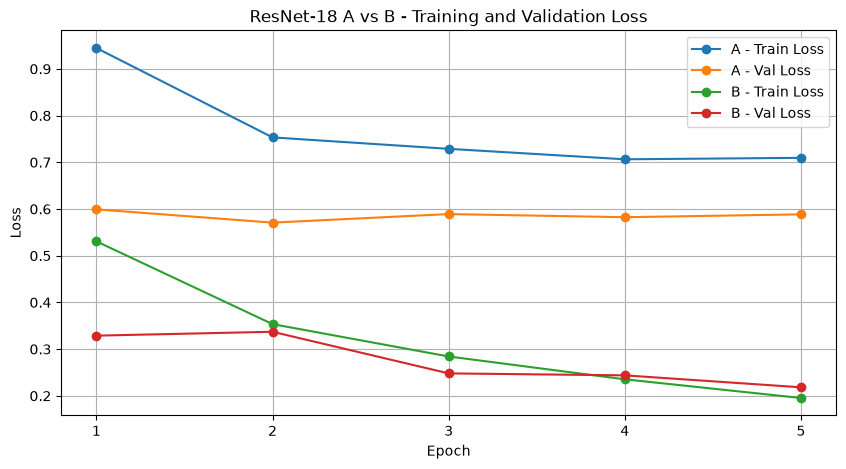

In [34]:
import matplotlib.pyplot as plt

epochs = range(1, 6)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    history_a["train_loss"],
    marker="o",
    label="A - Train Loss"
)

plt.plot(
    epochs,
    history_a["val_loss"],
    marker="o",
    label="A - Val Loss"
)

plt.plot(
    epochs,
    history_b["train_loss"],
    marker="o",
    label="B - Train Loss"
)

plt.plot(
    epochs,
    history_b["val_loss"],
    marker="o",
    label="B - Val Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-18 A vs B - Training and Validation Loss")
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.show()

Loss: ResNet-18 A giảm Train Loss từ 0.9447 → 0.7095, nhưng Val Loss chỉ dao động quanh 0.57–0.60. Điều này cho thấy khi chỉ train fc, khả năng thích nghi với CIFAR-10 khá hạn chế. ResNet-18 B tốt hơn rõ rệt: Train Loss 0.5307 → 0.1953, Val Loss 0.3288 → 0.2182.

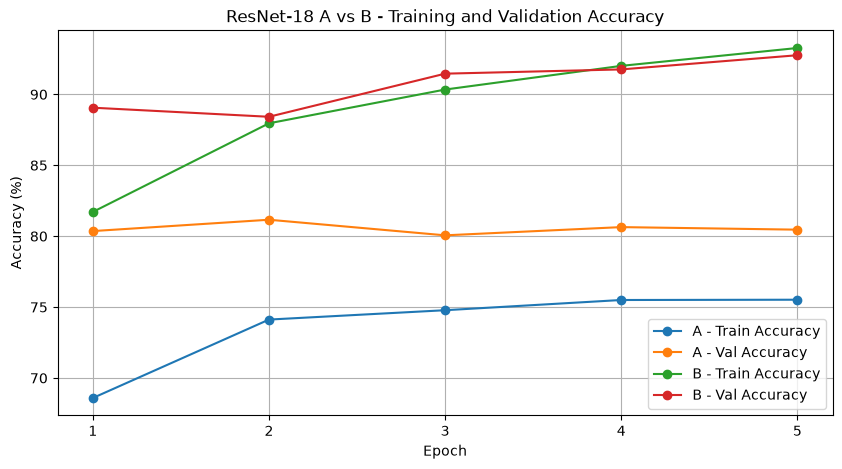

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    history_a["train_acc"],
    marker="o",
    label="A - Train Accuracy"
)

plt.plot(
    epochs,
    history_a["val_acc"],
    marker="o",
    label="A - Val Accuracy"
)

plt.plot(
    epochs,
    history_b["train_acc"],
    marker="o",
    label="B - Train Accuracy"
)

plt.plot(
    epochs,
    history_b["val_acc"],
    marker="o",
    label="B - Val Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet-18 A vs B - Training and Validation Accuracy")
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.show()

Accuracy: A tăng Train Accuracy nhưng Val Accuracy gần như dừng quanh 80%, tốt nhất 81.16% ở epoch 2. Trong khi đó B tiếp tục cải thiện và đạt 92.76% ở epoch 5. B cao hơn A 11.60 điểm phần trăm về Best Validation Accuracy.

## 11. Nhận xét và kết luận

Kết quả thực nghiệm cho thấy chiến lược fine-tuning `layer4 + fc` của ResNet-18 B đạt hiệu quả tốt hơn rõ rệt so với chiến lược chỉ huấn luyện lớp `fc` của ResNet-18 A.

### ResNet-18 A – FC only

Ở thí nghiệm A, toàn bộ backbone của ResNet-18 được đóng băng và chỉ lớp `fc` được huấn luyện với 5,130 tham số có thể cập nhật.

Validation Accuracy tốt nhất đạt **81.16% tại epoch 2**. Sau epoch 2, Validation Accuracy dao động quanh mức 80% và Validation Loss không tiếp tục giảm ổn định. Điều này cho thấy việc chỉ cập nhật classifier cuối hạn chế khả năng thích nghi của các đặc trưng ImageNet với dữ liệu CIFAR-10.

### ResNet-18 B – Fine-tuning layer4 + fc

Ở thí nghiệm B, `layer4` và `fc` được mở để fine-tuning, tương ứng với **8,398,858 tham số có thể cập nhật**.

Mô hình cải thiện rõ rệt qua các epoch. Train Loss giảm từ **0.5307 xuống 0.1953**, trong khi Validation Loss giảm xuống **0.2182**. Validation Accuracy tốt nhất đạt **92.76% tại epoch 5**.

So với ResNet-18 A, ResNet-18 B cải thiện Best Validation Accuracy từ **81.16% lên 92.76%**, tương ứng tăng **11.60 điểm phần trăm**.

### Kết luận

Kết quả cho thấy việc fine-tuning các đặc trưng mức cao trong `layer4` giúp ResNet-18 thích nghi tốt hơn với CIFAR-10 so với việc chỉ huấn luyện lớp phân loại cuối.

Trong hai chiến lược được thử nghiệm, **ResNet-18 B (`layer4 + fc`) là mô hình tốt hơn**, đạt Best Validation Accuracy **92.76%**.

Checkpoint tốt nhất của hai thí nghiệm:

 `resnet18_fc_only_best.pth`
 
 `resnet18_layer4_fc_best.pth`

In [37]:
from pathlib import Path
import torch

checkpoint_dir = Path("../checkpoints")

checkpoint_a = checkpoint_dir / "resnet18_fc_only_best.pth"
checkpoint_b = checkpoint_dir / "resnet18_layer4_fc_best.pth"

print("===== CHECKPOINT VERIFICATION =====")

for name, path in [
    ("ResNet-18 A", checkpoint_a),
    ("ResNet-18 B", checkpoint_b)
]:
    print(f"\n{name}")
    print("Path   :", path)
    print("Exists :", path.exists())

    if path.exists():
        print("Size   :", f"{path.stat().st_size / (1024**2):.2f} MB")

===== CHECKPOINT VERIFICATION =====

ResNet-18 A
Path   : ..\checkpoints\resnet18_fc_only_best.pth
Exists : True
Size   : 42.77 MB

ResNet-18 B
Path   : ..\checkpoints\resnet18_layer4_fc_best.pth
Exists : True
Size   : 106.83 MB
